<a href="https://colab.research.google.com/github/Shubhra-B/perturbsci/blob/main/xu_etal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE218566&format=file" -O GSE218566_RAW.tar
!tar -xvf GSE218566_RAW.tar

--2026-05-20 09:15:22--  https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE218566&format=file
Resolving www.ncbi.nlm.nih.gov (www.ncbi.nlm.nih.gov)... 130.14.29.110, 2607:f220:41e:4290::110
Connecting to www.ncbi.nlm.nih.gov (www.ncbi.nlm.nih.gov)|130.14.29.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 540948480 (516M) [application/x-tar]
Saving to: ‘GSE218566_RAW.tar’

GSE218566_RAW.tar   100%[===================>] 515.89M  21.1MB/s    in 26s     

2026-05-20 09:15:49 (19.8 MB/s) - ‘GSE218566_RAW.tar’ saved [540948480/540948480]

GSM6752591_on_target_cell_metadata.csv.gz
GSM6752591_on_target_nascent_tx.Barcodes.tsv.gz
GSM6752591_on_target_nascent_tx.Genes.tsv.gz
GSM6752591_on_target_nascent_tx_count_matrix.mtx.gz
GSM6752591_on_target_sgRNA.Barcodes.tsv.gz
GSM6752591_on_target_sgRNA.Genes.tsv.gz
GSM6752591_on_target_sgRNA_count_matrix.mtx.gz
GSM6752591_on_target_whole_tx.Barcodes.tsv.gz
GSM6752591_on_target_whole_tx.Genes.tsv.gz
GSM6752591_on_target_whol

In [ ]:
import scanpy as sc

whole   = sc.read_mtx("GSM6752591_on_target_whole_tx_count_matrix.mtx.gz").T #run matrix
whole.var_names = pd.read_csv("GSM6752591_on_target_whole_tx.Genes.tsv.gz",    header=None)[0].values #run gene names
whole.obs_names = pd.read_csv("GSM6752591_on_target_whole_tx.Barcodes.tsv.gz", header=None)[0].values #run guide names

nascent = sc.read_mtx("GSM6752591_on_target_nascent_tx_count_matrix.mtx.gz").T
nascent.var_names = pd.read_csv("GSM6752591_on_target_nascent_tx.Genes.tsv.gz",    header=None)[0].values
nascent.obs_names = pd.read_csv("GSM6752591_on_target_nascent_tx.Barcodes.tsv.gz", header=None)[0].values

sgRNA   = sc.read_mtx("GSM6752591_on_target_sgRNA_count_matrix.mtx.gz").T
sgRNA.var_names = pd.read_csv("GSM6752591_on_target_sgRNA.Genes.tsv.gz",    header=None)[0].values
sgRNA.obs_names = pd.read_csv("GSM6752591_on_target_sgRNA.Barcodes.tsv.gz", header=None)[0].values

print(whole.shape, nascent.shape, sgRNA.shape)

(98315, 59429) (98315, 59429) (98315, 699)


In [ ]:
meta = pd.read_csv("GSM6752591_on_target_cell_metadata.csv.gz")
print(meta.columns.tolist())
meta.head()
print(meta['target_genes'].value_counts().head(10))
print((meta['target_genes'] == 'STAG2').sum())
print(meta['target_genes'].str.startswith('NO-TARGET', na=False).sum())

['cell_names', 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio']
target_genes
NO-TARGET    2758
SMARCD1      2158
SLC25A1      1880
XPO5         1583
LDHA         1437
SEC62        1375
ARID2        1309
DLAT         1256
PDHA1        1184
ATP11A       1167
Name: count, dtype: int64
1074
2758


group
NTC         2758
STAG2_KD    1074
Name: count, dtype: int64


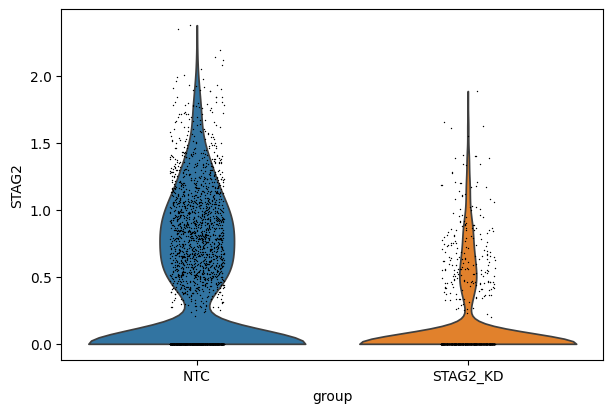

In [ ]:
stag2_cells = meta.loc[meta['target_genes'] == 'STAG2',     'cell_names'].tolist()
ntc_cells   = meta.loc[meta['target_genes'] == 'NO-TARGET', 'cell_names'].tolist()

adata = whole[stag2_cells + ntc_cells].copy()
adata.obs['group'] = np.where(adata.obs_names.isin(stag2_cells), 'STAG2_KD', 'NTC')
print(adata.obs['group'].value_counts())

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pl.violin(adata, keys='STAG2', groupby='group')

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse, stats

# Get raw counts (before normalization)
adata_raw = whole[stag2_cells + ntc_cells].copy()
adata_raw.obs['group'] = np.where(adata_raw.obs_names.isin(stag2_cells), 'STAG2_KD', 'NTC')

def pseudobulk(adata, group_col, group):
    mask = (adata.obs[group_col] == group).values   # <-- .values converts to numpy array
    X = adata.X[mask].sum(axis=0)
    return np.asarray(X).flatten()

pb_stag2 = pseudobulk(adata_raw, 'group', 'STAG2_KD')
pb_ntc   = pseudobulk(adata_raw, 'group', 'NTC')

# CPM normalize
pb_stag2_cpm = pb_stag2 / pb_stag2.sum() * 1e6
pb_ntc_cpm   = pb_ntc   / pb_ntc.sum()   * 1e6

# Compute log2FC + a simple per-gene test (chi-sq on counts)
results = pd.DataFrame({
    'gene':       adata_raw.var_names.values,
    'cpm_stag2':  pb_stag2_cpm,
    'cpm_ntc':    pb_ntc_cpm,
    'log2FC':     np.log2((pb_stag2_cpm + 1) / (pb_ntc_cpm + 1)),
    'count_stag2': pb_stag2,
    'count_ntc':   pb_ntc,
})

# Filter: gene must be expressed (>=5 CPM in at least one group)
results = results[(results['cpm_stag2'] >= 5) | (results['cpm_ntc'] >= 5)].copy()
print(f"Genes tested: {len(results)}")

# Sort by log2FC
results = results.sort_values('log2FC')
print("\nTop 10 DOWN in STAG2 KD:")
print(results.head(10)[['gene','cpm_stag2','cpm_ntc','log2FC']])
print("\nTop 10 UP in STAG2 KD:")
print(results.tail(10)[['gene','cpm_stag2','cpm_ntc','log2FC']])

results[results['gene'].isin(['STAG1','STAG2','RAD21','SMC1A','SMC3','MAU2','NIPBL'])]

Genes tested: 12205

Top 10 DOWN in STAG2 KD:
                 gene   cpm_stag2     cpm_ntc    log2FC
58227           STAG2  112.919853  394.554474 -1.795857
49111       LINC01915    2.493498    7.534643 -1.288658
30037      ZNF503-AS2    3.205926    9.128510 -1.267926
51130    RP11-15H20.7    1.781070    5.650982 -1.257927
11904    RP11-379F4.4    2.493498    7.244849 -1.238821
45604            CTU2    1.781070    5.361188 -1.193656
8174          CCDC173    2.137284    5.940776 -1.145581
3353              GBA    2.493498    6.665261 -1.133663
56456          SHANK3    3.562140    8.983613 -1.129851
30453  RP11-548K23.11    1.781070    5.071394 -1.126388

Top 10 UP in STAG2 KD:
             gene  cpm_stag2   cpm_ntc    log2FC
52683       ZFP28   5.343210  1.883661  1.137312
16407       CKMT2   5.343210  1.883661  1.137312
21181       ELFN1   5.343210  1.738764  1.211688
33149        RELT  12.467491  4.636703  1.256558
23314        GRM8   8.192923  2.608146  1.349266
23951       WDR86   

,gene,cpm_stag2,cpm_ntc,log2FC,count_stag2,count_ntc
58227,STAG2,112.919853,394.554474,-1.795857,317.0,2723.0
30681,SMC3,340.896820,358.475128,-0.072331,957.0,2474.0
26019,RAD21,352.651886,352.679260,-0.000112,990.0,2434.0
15737,NIPBL,441.349182,429.909363,0.037801,1239.0,2967.0
57280,SMC1A,446.336182,429.474670,0.055431,1253.0,2964.0
50938,MAU2,90.834572,79.403542,0.191778,255.0,548.0
11526,STAG1,221.565140,193.582367,0.193847,622.0,1336.0


In [1]:
!git config --global user.email "shubhrab16@gmail.com"

In [2]:
!git config --global user.name "Shubhra-B"

In [ ]:
from google.colab import userdata  # or just paste the token

In [ ]:
from google.colab import userdata
userdata.get('secretName')

In [7]:
from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')   # the NAME of the secret
!git config --global user.email "shubhrab16@gmail.com"
!git config --global user.name "Shubhra-B"

!git clone https://$TOKEN@github.com/Shubhra-B/perturbsci.git
%cd perturbsci

Cloning into 'perturbsci'...
/content/perturbsci
